In [ ]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(dplyr)
  library(NMF)
  library(pdacR)
})
##hello

Warning message:
“replacing previous import ‘Seurat::Assays’ by ‘SummarizedExperiment::Assays’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘ggpubr::mutate’ by ‘plyr::mutate’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘Biobase::exprs’ by ‘rlang::exprs’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘readr::col_factor’ by ‘scales::col_factor’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘shiny::runExample’ by ‘shinyjs::runExample’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘limma::show’ by ‘shinyjs::show’ when loading ‘pdacR’”


In [ ]:
pdacR::gene_lists

## Loading data

In [3]:
met_high_df <- read.csv("/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/met-high-genes-human.csv")
met_low_df  <- read.csv("/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/met-low-genes-human.csv")
met_high_genes <- na.omit(met_high_df$SYMBOL)
met_low_genes  <- na.omit(met_low_df$SYMBOL)

file_path <- system.file("data", "TCGA_PAAD.rds", package = "pdacR")
TCGA_PAAD <- readRDS(file_path)

### Checking Overlaps

In [5]:
group_lists <- list(
  "Basal-like" = gene_lists$Moffitt.F6_BasalLike.top250,
  "Classical" = gene_lists$Moffitt.F8_Classical.top250,
  "Endocrine" = gene_lists$Moffitt.F12_Endocrine.top250,
  "Exocrine" = gene_lists$Moffitt.F3_Exocrine.top250,
  "Activated Stroma" = gene_lists$Moffitt.F5_ActivatedStroma.top250,
  "Normal Stroma" = gene_lists$Moffitt.F13_NormalStroma.top250,
  "Immune" = gene_lists$Moffitt.F7_Immune.top250,
  "MetHigh" = met_high_genes,  
  "MetLow" = met_low_genes
)


all_genes <- unlist(group_lists)

gene_counts <- table(all_genes)

overlapping_genes <- names(gene_counts[gene_counts > 1])


overlap_locations <- sapply(overlapping_genes, function(gene) {

  found_in_groups <- names(group_lists)[sapply(group_lists, function(g) gene %in% g)]
  
  paste(found_in_groups, collapse = " + ")
})


overlap_details_df <- data.frame(
  Gene = overlapping_genes,
  Belongs_To_Groups = overlap_locations,
  row.names = NULL
)


print(overlap_details_df)

        Gene          Belongs_To_Groups
1     ATP2C2        Classical + MetHigh
2      BCAR3       Basal-like + MetHigh
3      CCDC3     Normal Stroma + MetLow
4       CD34     Normal Stroma + MetLow
5      CHRM3          Exocrine + MetLow
6     CTHRC1  Activated Stroma + MetLow
7    CTTNBP2          Exocrine + MetLow
8     CYP2S1        Classical + MetHigh
9      DDIT4       Basal-like + MetHigh
10      DKK3  Activated Stroma + MetLow
11    DPYSL3  Activated Stroma + MetLow
12     FAM3B         Exocrine + MetHigh
13    FGFBP1       Basal-like + MetHigh
14      FMO2     Normal Stroma + MetLow
15     FSTL1  Activated Stroma + MetLow
16     GCNT3        Classical + MetHigh
17      GLI3  Activated Stroma + MetLow
18    GUCY2C         Classical + MetLow
19     HTRA3  Activated Stroma + MetLow
20      IL1A       Basal-like + MetHigh
21      ISL1         Endocrine + MetLow
22     LAMC2       Basal-like + MetHigh
23     LOXL4        Endocrine + MetHigh
24       MAL    Normal Stroma + MetHigh


In [6]:
overlap_details_df$Belongs_To_Groups <- as.factor(overlap_details_df$Belongs_To_Groups)


overlap_frequencies <- summary(overlap_details_df$Belongs_To_Groups)
print(overlap_frequencies)

Activated Stroma + MetHigh  Activated Stroma + MetLow 
                         1                          8 
      Basal-like + MetHigh        Classical + MetHigh 
                        13                          3 
        Classical + MetLow        Endocrine + MetHigh 
                         4                          3 
        Endocrine + MetLow         Exocrine + MetHigh 
                         1                          1 
         Exocrine + MetLow           Immune + MetHigh 
                         5                          1 
   Normal Stroma + MetHigh     Normal Stroma + MetLow 
                         2                          4 


### Deleting the duplicate genes from MetScore gene list

In [8]:
met_high_genes_clean <- setdiff(met_high_genes, overlapping_genes)
met_low_genes_clean <- setdiff(met_low_genes, overlapping_genes)


print(paste("[MetHigh] Original Count:", length(met_high_genes), 
            "-> Cleaned Count:", length(met_high_genes_clean)))

print(paste("[MetLow] Original Count:", length(met_low_genes), 
            "-> Cleaned Count:", length(met_low_genes_clean)))

[1] "[MetHigh] Original Count: 202 -> Cleaned Count: 178"
[1] "[MetLow] Original Count: 174 -> Cleaned Count: 152"


## Preparing TCGA

In [9]:
## Preparation of TCGA data
#RSEM counts can be rounded to the nearest integer
## RSEM assigns reads with multiple mappings -- they are counts, but a fractional amount can be assigned to a gene.
TCGA_PAAD$ex <- round(TCGA_PAAD$ex)


#remove expression of unhelpful "?" genes
#this gives the index of rows that are "?"
feat_q <- which(TCGA_PAAD$featInfo == "?")
## TCGA_PAAD is organized so that the rows of ex are in the same order as featInfo (feature info)
## and the columns of ex are in the same order as sampInfo (sample info)
# To maintain this order, removals need to be done to both 
TCGA_PAAD$ex <- TCGA_PAAD$ex[-feat_q,]
TCGA_PAAD$featInfo <- TCGA_PAAD$featInfo[-feat_q,]


#------------------

## "whitelist" filter determined by original TCGA paper
# remove the samples that are not part of the whitelist
wl_filter <- TCGA_PAAD$sampInfo$Filter_by == "whitelist"
TCGA_PAAD$sampInfo <- TCGA_PAAD$sampInfo[wl_filter,]
TCGA_PAAD$ex <- TCGA_PAAD$ex[,wl_filter]

#------------------


# remove TCGA-US-A776 (outlier, precursor tumor)
# This sample is part of the whitelist, but is not PDAC
USA776 <- which(TCGA_PAAD$sampInfo$Tumor.Sample.ID == "TCGA-US-A776-01A")
TCGA_PAAD$sampInfo <- TCGA_PAAD$sampInfo[-USA776,]
TCGA_PAAD$ex <- TCGA_PAAD$ex[,-USA776]

#------------------

## Some genes have 0 expression across all samples and can be removed
remove0 <- which(rowSums(TCGA_PAAD$ex) == 0)
TCGA_PAAD$ex <- TCGA_PAAD$ex[-remove0,]
TCGA_PAAD$featInfo <- TCGA_PAAD$featInfo[-remove0,]


## Check that they still have the same number of genes
dim(TCGA_PAAD$ex)

[1] 19840   149

In [10]:
dim(TCGA_PAAD$featInfo)

[1] 19840     2

## Preparing genelist (substituted with Jesse's met-high and met-low genelist)

In [13]:
metscore_genes <- data.frame(SYMBOL = met_high_genes_clean, class = "MetHigh") %>%
  rbind(data.frame(SYMBOL = met_low_genes_clean, class = "MetLow"))
head(metscore_genes)

,SYMBOL,class
,<chr>,<chr>
1,VMA21,MetHigh
2,RLIM,MetHigh
3,INO80C,MetHigh
4,NSDHL,MetHigh
5,GALNT1,MetHigh
6,LPIN1,MetHigh


In [14]:
rownames(metscore_genes) <- metscore_genes$SYMBOL

ex_metscore <- TCGA_PAAD$ex[TCGA_PAAD$featInfo$SYMBOL %in% metscore_genes$SYMBOL, ]
featInfo_metscore <- TCGA_PAAD$featInfo[TCGA_PAAD$featInfo$SYMBOL %in% metscore_genes$SYMBOL, ]

## Always want ex and featInfo to match - check the dimensions!
dim(ex_metscore)
dim(featInfo_metscore)

[1] 303 149

[1] 303   2

### Detecting the Missing genes

In [15]:
# metscore_genes has 376 values
expected_genes <- metscore_genes$SYMBOL

available_tcga_genes <- TCGA_PAAD$featInfo$SYMBOL

missing_genes <- setdiff(expected_genes, available_tcga_genes)

print(paste("Number of missing genes:", length(missing_genes)))

print(missing_genes)

[1] "Number of missing genes: 27"
 [1] "SPMIP3"   "CAVIN2"   "NABP1"    "CFAP69"   "CRACR2A"  "TENT5B"  
 [7] "ACKR3"    "TMEM238L" "JADE3"    "SEPTIN8"  "SOWAHB"   "NHSL3"   
[13] "ARHGAP40" "ENTREP1"  "NREP"     "PIEZO2"   "CCN3"     "CPED1"   
[19] "ADGRF5"   "AOPEP"    "GPR15LG"  "MALRD1"   "CLDN34"   "DENND11" 
[25] "ARHGAP44" "KNOP1"    "FAM222B" 


### Check if the genes are filtered

In [18]:
in_raw <- missing_genes %in% TCGA_PAAD$featInfo$SYMBOL


print(missing_genes[!in_raw])
print("None of the 27 missing genes were in the raw dataset to begin with.")

 [1] "SPMIP3"   "CAVIN2"   "NABP1"    "CFAP69"   "CRACR2A"  "TENT5B"  
 [7] "ACKR3"    "TMEM238L" "JADE3"    "SEPTIN8"  "SOWAHB"   "NHSL3"   
[13] "ARHGAP40" "ENTREP1"  "NREP"     "PIEZO2"   "CCN3"     "CPED1"   
[19] "ADGRF5"   "AOPEP"    "GPR15LG"  "MALRD1"   "CLDN34"   "DENND11" 
[25] "ARHGAP44" "KNOP1"    "FAM222B" 
[1] "None of the 27 missing genes were in the raw dataset to begin with."


## Setting up NMF

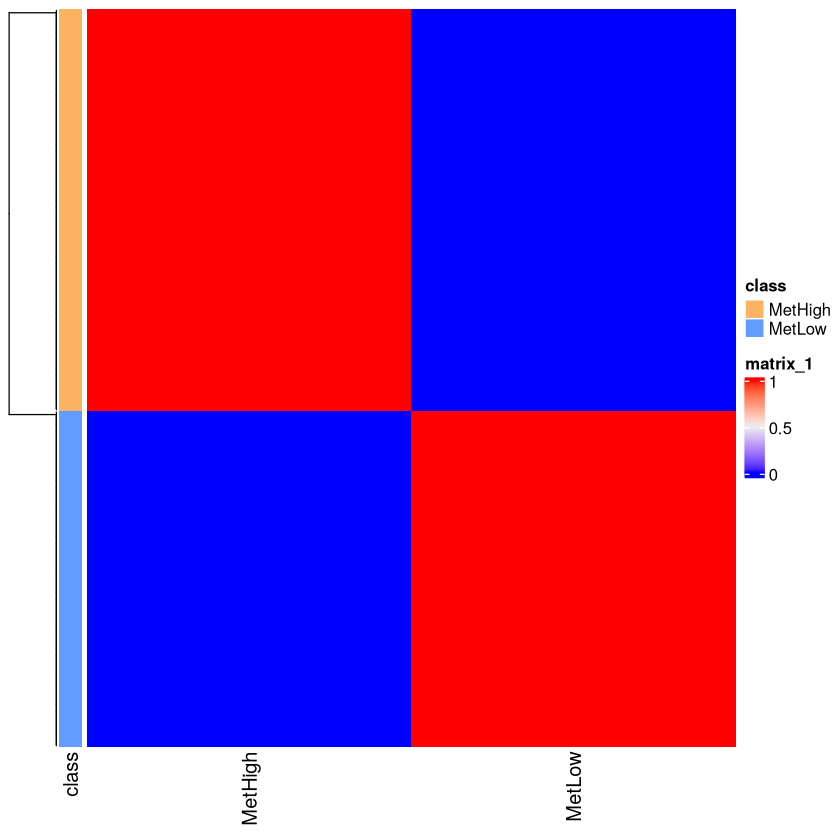

In [19]:
k = 2

RNA_val <- 1 
default_RNA <- 0.01

W.seed.rna <- matrix(default_RNA, nrow=nrow(ex_metscore), ncol=k)

W.seed.rna[which(featInfo_metscore$SYMBOL %in% met_high_genes), 1] <- RNA_val
W.seed.rna[which(featInfo_metscore$SYMBOL %in% met_low_genes), 2]  <- RNA_val

colnames(W.seed.rna) <- c("MetHigh", "MetLow")

Heatmap(W.seed.rna, cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          df = metscore_genes[featInfo_metscore$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("MetHigh" = "#fdb462", "MetLow" = "#619cff") # Picked distinct colors
          )
        )
)




In [20]:
H.seed.rna <- matrix(0.05, nrow=k, ncol=ncol(ex_metscore))

H.seed.rna <- nmf_update.euclidean.h(ex_metscore, W.seed.rna, H.seed.rna)


In [21]:
RNA_seed <- NMF::nmfModel(W = W.seed.rna, H = H.seed.rna)

RNA_solved <- NMF::nmf(ex_metscore, seed=RNA_seed, .opt=list(parallel=TRUE, verbose=FALSE))

## Solution to W matrix for RNA

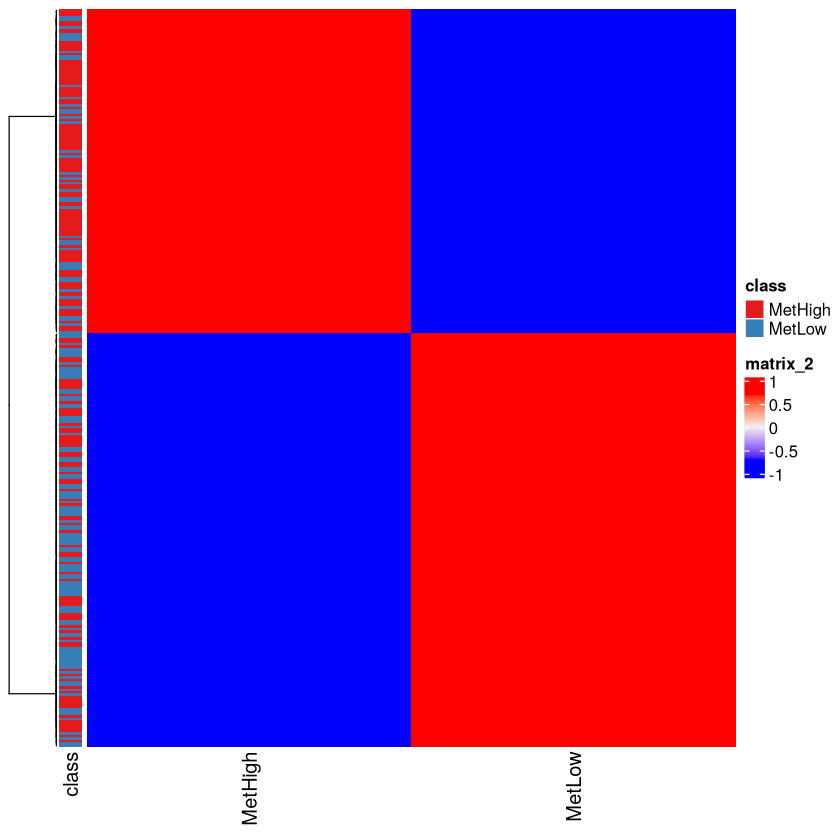

In [22]:

RNA_W <- RNA_solved@fit@W


Heatmap(t(scale(t(RNA_W))), cluster_columns = FALSE, cluster_rows = TRUE,

        left_annotation = rowAnnotation(
          df = metscore_genes[featInfo_metscore$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("MetHigh" = "#E41A1C", "MetLow" = "#377EB8") 
          )
        )
)

## Solution to H matrix for RNA

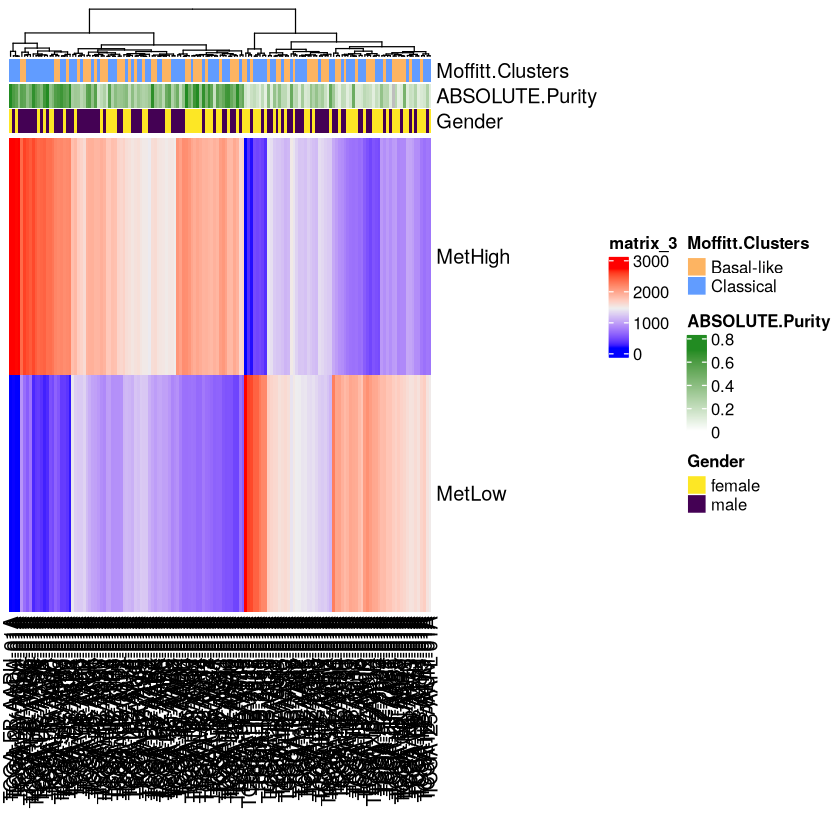

In [23]:
RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID

rownames(RNA_H) <- c("MetHigh", "MetLow")

Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE,
        ## Keep the original patient annotations to see how they align with the scores
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            Moffitt.Clusters = c("Basal-like" = "#fdb462", "Classical" = "#619cff"),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

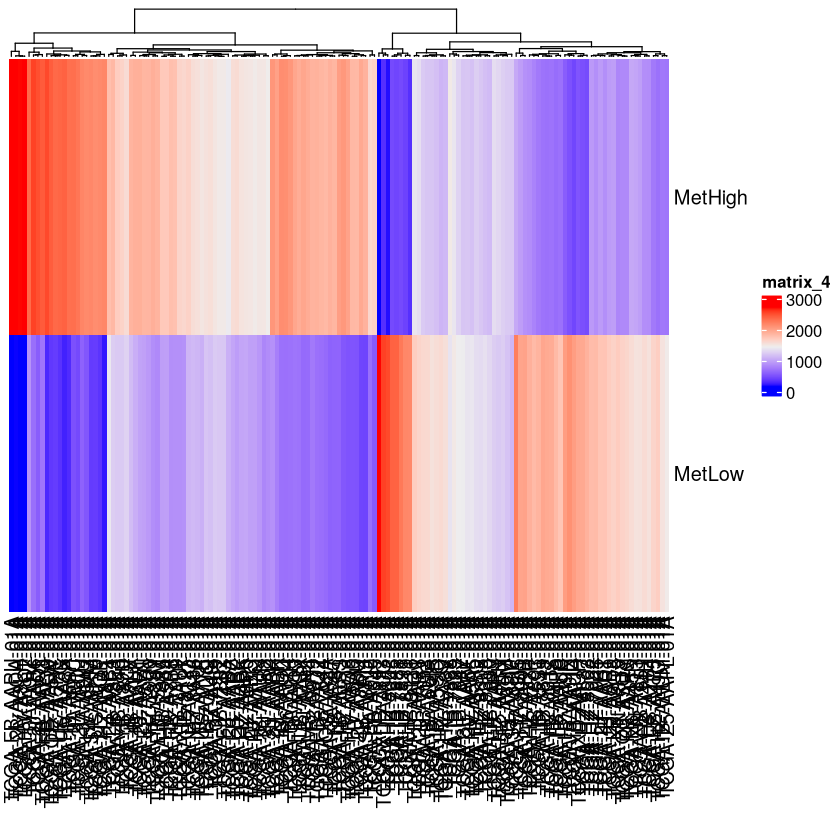

In [24]:
# No extra annotations

RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID

rownames(RNA_H) <- c("MetHigh", "MetLow")

Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE)

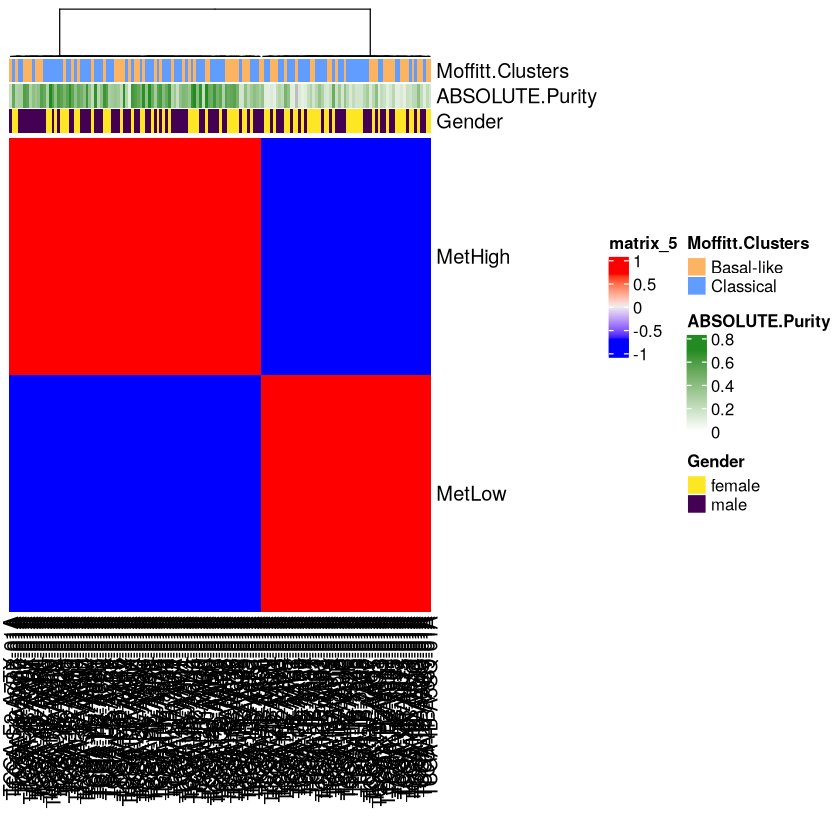

In [25]:


Heatmap(scale(RNA_H), cluster_columns = T, cluster_rows=F,
        ## Set the colors of our features manually
        top_annotation = HeatmapAnnotation(df=subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
                                           col=list(
                                             ABSOLUTE.Purity=colorRamp2(c(0, .7), c("white", "forestgreen")),
                                             Moffitt.Clusters = c("Basal-like"="#fdb462","Classical"="#619cff"),
                                             Gender=c("male"="#440154", "female"="#fde725")
                                           ))
)

# With other classification

In [28]:
combined_genelist <- data.frame(SYMBOL=gene_lists$Moffitt.F6_BasalLike.top250, class="Basal-like") %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F8_Classical.top250, class="Classical")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F12_Endocrine.top250, class="Endocrine")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F3_Exocrine.top250, class="Exocrine")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F5_ActivatedStroma.top250, class="Activated Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F13_NormalStroma.top250, class="Normal Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F7_Immune.top250, class="Immune")) %>%
  rbind(data.frame(SYMBOL=met_high_genes_clean, class="MetHigh")) %>%    
  rbind(data.frame(SYMBOL=met_low_genes_clean, class="MetLow"))          

In [29]:
rownames(combined_genelist) <- combined_genelist$SYMBOL

ex_combined <- TCGA_PAAD$ex[TCGA_PAAD$featInfo$SYMBOL %in% combined_genelist$SYMBOL, ]
featInfo_combined <- TCGA_PAAD$featInfo[TCGA_PAAD$featInfo$SYMBOL %in% combined_genelist$SYMBOL, ]


dim(ex_combined)
dim(featInfo_combined)

[1] 1925  149

[1] 1925    2

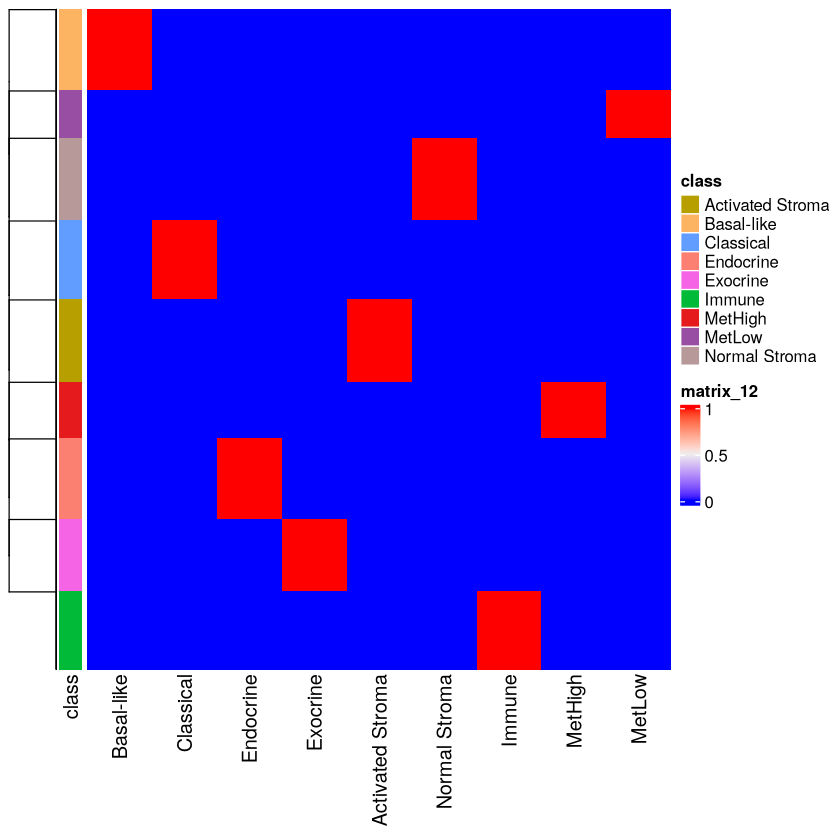

In [36]:
k <- 9
RNA_val <- 1
default_RNA <- 0.01


W.seed.rna <- matrix(default_RNA, nrow=nrow(ex_combined), ncol=k)


W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F6_BasalLike.top250), 1] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F8_Classical.top250), 2] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F12_Endocrine.top250), 3] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F3_Exocrine.top250), 4] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F5_ActivatedStroma.top250), 5] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F13_NormalStroma.top250), 6] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F7_Immune.top250), 7] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% met_high_genes_clean), 8] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% met_low_genes_clean), 9] <- RNA_val


colnames(W.seed.rna) <- c("Basal-like", "Classical", "Endocrine", "Exocrine",
                          "Activated Stroma", "Normal Stroma", "Immune",
                          "MetHigh", "MetLow")


Heatmap(W.seed.rna, cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          df = combined_genelist[featInfo_combined$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("Basal-like" = "#fdb462", "Classical" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38", "MetHigh" = "#E41A1C", "MetLow" = "#984EA3")
          )
        )
)



In [38]:
H.seed.rna <- matrix(0.05, nrow=k, ncol=ncol(ex_combined))

H.seed.rna <- nmf_update.euclidean.h(ex_combined, W.seed.rna, H.seed.rna)

In [39]:
RNA_seed <- NMF::nmfModel(W = W.seed.rna, H = H.seed.rna)

RNA_solved <- NMF::nmf(ex_combined, seed=RNA_seed, .opt=list(parallel=TRUE, verbose=FALSE))

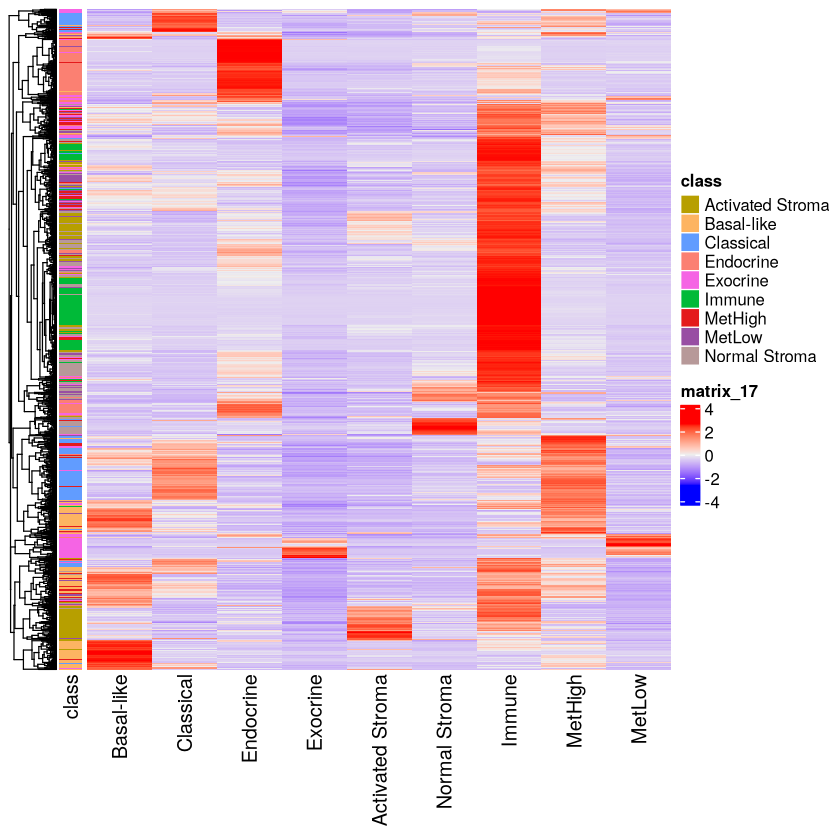

In [44]:
RNA_W <- RNA_solved@fit@W

Heatmap(t(scale(t(RNA_W))), cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          
          df = combined_genelist[featInfo_combined$SYMBOL, "class", drop = FALSE],
          col = list(
            
            class = c("Basal-like" = "#fdb462", "Classical" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38", "MetHigh" = "#E41A1C", "MetLow" = "#984EA3")
          )
        )
)

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.



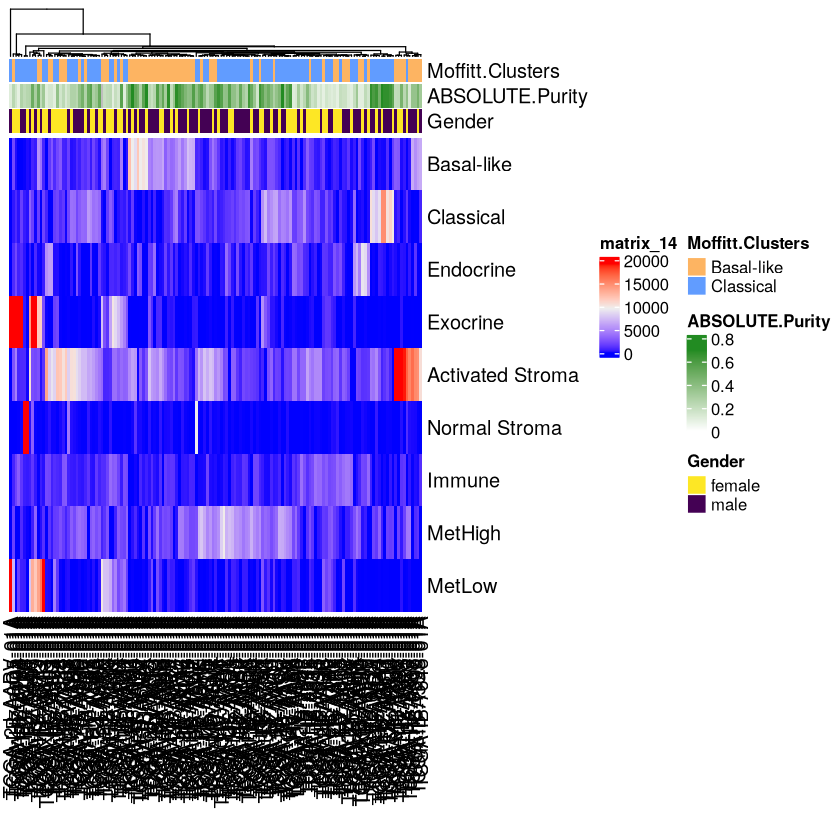

In [41]:
RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID


rownames(RNA_H) <- c("Basal-like", "Classical", "Endocrine", "Exocrine",
                     "Activated Stroma", "Normal Stroma", "Immune",
                     "MetHigh", "MetLow")

Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            Moffitt.Clusters = c("Basal-like" = "#fdb462", "Classical" = "#619cff"),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

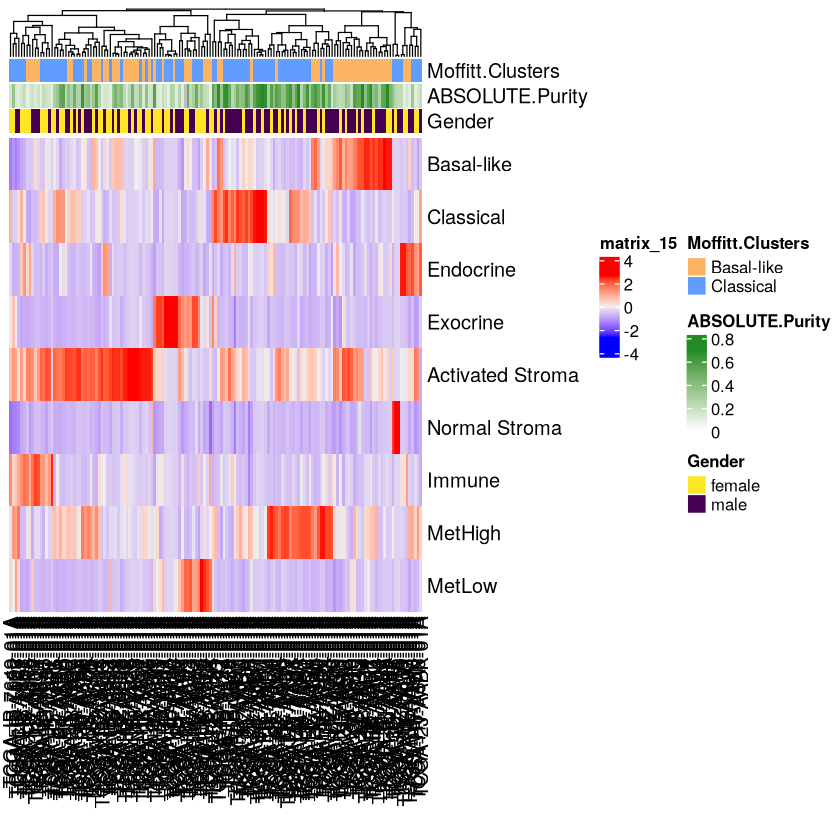

In [42]:
Heatmap(scale(RNA_H), cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            Moffitt.Clusters = c("Basal-like" = "#fdb462", "Classical" = "#619cff"),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)